# LSTM Autoencoder for ECG Anomaly Detection

This notebook introduces the first deep reconstruction model in the project.

The progression is:

- **ARMA** models local temporal dependencies with a classical linear time-series model.
- **PCA** reconstructs each beat with a linear low-dimensional representation.
- **LSTM Autoencoder** reconstructs each beat as an ordered sequence, allowing nonlinear temporal patterns.

The anomaly score is still the reconstruction error. This keeps the evaluation logic comparable with ARMA and PCA.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import LSTMAutoencoderAnomalyDetector

## Load Records

We keep the same 5-record subset used for ARMA and PCA. This makes the first comparison easier and keeps training time controlled.

In [2]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '103', '105', '106']


## Create Beat Dataset

Each row is one beat window of 180 samples. The label belongs to the whole beat segment.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10818, 7)

,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     10211
anomaly      607
Name: count, dtype: int64

symbol
N    10211
V      562
A       38
Q        7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10818, 180)
y shape: (10818,)


## Train/Test Split by Record

The split is performed by record to reduce leakage between train and test beats.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '103', '105']
Test records: ['106']
Train shape: (8791, 180)
Test shape: (2027, 180)
Train labels:


normal     8704
anomaly      87
Name: count, dtype: int64

Test labels:


normal     1507
anomaly     520
Name: count, dtype: int64

## Fit LSTM Autoencoder

The model is trained only on normal training beats. This follows a semi-supervised anomaly detection setup: the autoencoder learns to reconstruct normal morphology, and anomalous beats should produce larger reconstruction errors.

For this first experiment we use a limited number of normal training beats to keep runtime manageable.

In [6]:
MAX_TRAIN_NORMAL = 1000
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

Normal training beats used: 1000
Test beats used: 300


anomaly    150
normal     150
Name: count, dtype: int64

PyTorch device: cuda


In [7]:
lstm_ae = LSTMAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN,
    hidden_size=16,
    latent_dim=8,
    threshold_percentile=95,
    learning_rate=1e-3,
    batch_size=64,
    epochs=10,
    random_state=config.RANDOM_SEED,
)

lstm_ae.fit(X_train_normal)

print("Threshold:", lstm_ae.threshold)
print("Final training loss:", lstm_ae.history[-1])

Threshold: 0.011409192066639652
Final training loss: 0.009306806197855622


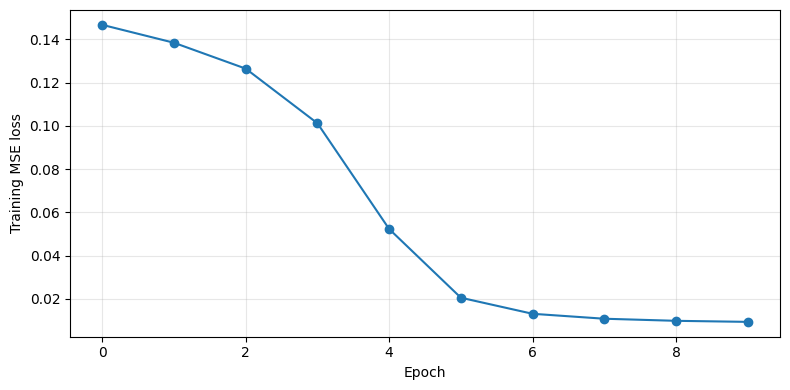

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_ae.history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training MSE loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate

In [9]:
scores = lstm_ae.anomaly_score(X_test_eval)
y_pred = lstm_ae.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[140, 10], [0, 150]],
 'precision': 0.9375,
 'recall': 1.0,
 'f1': 0.967741935483871,
 'roc_auc': 0.9992000000000001,
 'pr_auc': 0.999189571288444}

### Metric Interpretation

On this subset the LSTM autoencoder separates the two classes almost perfectly: ROC-AUC and PR-AUC are essentially 1.0, and at the default 95th-percentile threshold recall is 1.0 with precision ~0.94 (a few normal beats fall just above the threshold).

Record 106's anomalies are mostly high-energy ventricular beats, which are easy to separate by reconstruction error. The full-dataset experiment (notebook 07) gives a more realistic — and much harder — picture.

## Threshold Sensitivity

As with ARMA and PCA, the threshold converts reconstruction scores into binary predictions. We inspect several percentiles instead of assuming that the default 95th percentile is always appropriate.

In [10]:
threshold_results = []
train_scores = lstm_ae.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.011409,0.937500,1.000000,0.967742,0.9992,0.99919
1,97.0,0.029661,0.992806,0.920000,0.955017,0.9992,0.99919
2,98.0,0.102981,1.000000,0.660000,0.795181,0.9992,0.99919
3,99.0,0.177341,1.000000,0.373333,0.543689,0.9992,0.99919
4,99.5,0.249547,1.000000,0.133333,0.235294,0.9992,0.99919
5,99.9,0.323896,1.000000,0.020000,0.039216,0.9992,0.99919


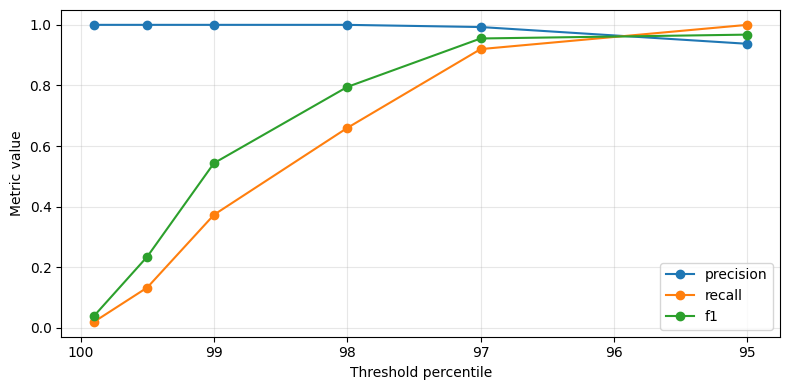

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

The score separates the classes very well (AUC ~1.0), so the threshold mostly trades precision against recall: at the 95th percentile recall is 1.0 with a few false positives, and raising the percentile pushes precision to 1.0 while recall drops. The right operating point depends on the relative cost of false positives and false negatives.

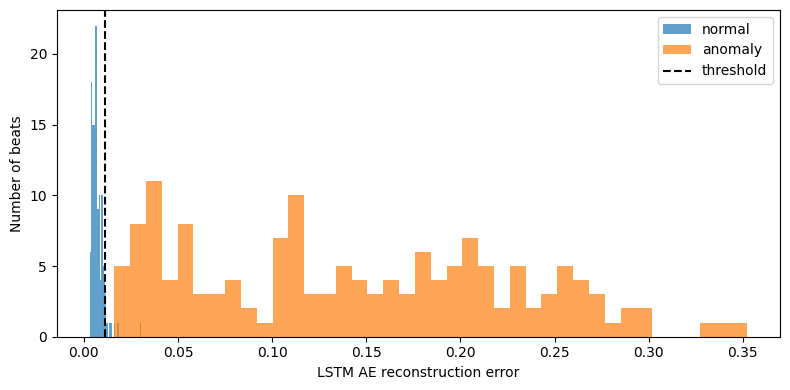

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(lstm_ae.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("LSTM AE reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- LSTM AE is the first nonlinear sequential reconstruction model in the project: each beat is treated as an ordered sequence of 180 samples.
- The encoder is an LSTM; the decoder is a dense head that reconstructs the whole beat from the latent vector (a recurrent decoder fed a repeated constant collapses to a flat output).
- The model is trained on normal beats and scored by reconstruction error.
- On this subset it separates the classes almost perfectly, because record 106's anomalies are high-energy ventricular beats that the model reconstructs poorly.
- **Caveat:** the test set is a single record (106), so these numbers are volatile and optimistic; the full-dataset experiment is needed before concluding that the LSTM beats the simpler baselines.
- The next models (VAE, CfC) are compared under the same protocol.